# Step 2: Exploratory Data Analysis (EDA)
## Wing Shop Demand Forecasting Project

This notebook explores sales patterns, trends, and seasonality in the data.

**Objectives:**
- Understand sales distribution and statistics
- Analyze time-based patterns (daily, weekly, monthly)
- Identify product performance
- Assess promotion and holiday impacts
- Check data stationarity for forecasting

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Setup directories
BASE_DIR = os.path.dirname(os.getcwd()) if 'notebooks' in os.getcwd() else os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, 'data')

print(f"Data Directory: {DATA_DIR}")

Data Directory: d:\CADT\InternshipII\forecasting\data


In [3]:
# Load processed data
def load_processed_data():
    """Load processed sales data"""
    filepath = os.path.join(DATA_DIR, 'processed_sales.csv')
    if os.path.exists(filepath):
        df = pd.read_csv(filepath, parse_dates=['date'])
        return df
    else:
        filepath = os.path.join(DATA_DIR, r'D:\CADT\InternshipII\forecasting\data\processed_sales.csv')
        if os.path.exists(filepath):
            return pd.read_csv(filepath, parse_dates=['date'])
    return None

df = load_processed_data()

if df is not None:
    print(f"Data loaded successfully: {df.shape}")
else:
    print("Error: No data found. Please run 01_data_loading.ipynb first.")

Data loaded successfully: (42775, 16)


## 2.1 Dataset Overview

In [4]:
print("=" * 60)
print("STEP 2: EXPLORATORY DATA ANALYSIS")
print("=" * 60)

print("\n[1] DATASET OVERVIEW")
print("-" * 40)
print(f"Total records: {len(df):,}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Number of days: {df['date'].nunique()}")

if 'store_nbr' in df.columns:
    print(f"Number of stores: {df['store_nbr'].nunique()}")

product_col = 'family' if 'family' in df.columns else 'product'
if product_col in df.columns:
    print(f"Number of product categories: {df[product_col].nunique()}")

STEP 2: EXPLORATORY DATA ANALYSIS

[1] DATASET OVERVIEW
----------------------------------------
Total records: 42,775
Date range: 2013-01-02 to 2017-08-15
Number of days: 1678
Number of stores: 1
Number of product categories: 32


In [5]:
# Data info and types
print("\nColumn Data Types:")
df.info()


Column Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42775 entries, 0 to 42774
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            42775 non-null  datetime64[ns]
 1   store_nbr       42775 non-null  int64         
 2   family          42775 non-null  object        
 3   unit_sales      42775 non-null  float64       
 4   onpromotion     42775 non-null  float64       
 5   transactions    42720 non-null  float64       
 6   dcoilwtico      42775 non-null  float64       
 7   is_holiday      42775 non-null  int64         
 8   year            42775 non-null  int64         
 9   month           42775 non-null  int64         
 10  day             42775 non-null  int64         
 11  dayofweek       42775 non-null  int64         
 12  weekofyear      42775 non-null  int64         
 13  is_weekend      42775 non-null  int64         
 14  is_month_start  42775 non-null  in

In [6]:
# Sales statistics
print("\n[2] SALES STATISTICS")
print("-" * 40)
print(df['unit_sales'].describe())


[2] SALES STATISTICS
----------------------------------------
count    42775.000000
mean       331.444830
std        663.752062
min         -1.000000
25%          9.000000
50%         78.000000
75%        272.190000
max       9065.000000
Name: unit_sales, dtype: float64


## 2.2 Time Pattern Analysis

In [7]:
print("\n[3] TIME PATTERN ANALYSIS")
print("-" * 40)

# Daily sales trend
daily_sales = df.groupby('date')['unit_sales'].sum().reset_index()

print(f"Average daily sales: {daily_sales['unit_sales'].mean():,.0f}")
print(f"Max daily sales: {daily_sales['unit_sales'].max():,.0f}")
print(f"Min daily sales: {daily_sales['unit_sales'].min():,.0f}")
print(f"Std deviation: {daily_sales['unit_sales'].std():,.0f}")


[3] TIME PATTERN ANALYSIS
----------------------------------------
Average daily sales: 8,449
Max daily sales: 25,703
Min daily sales: 1,199
Std deviation: 3,433


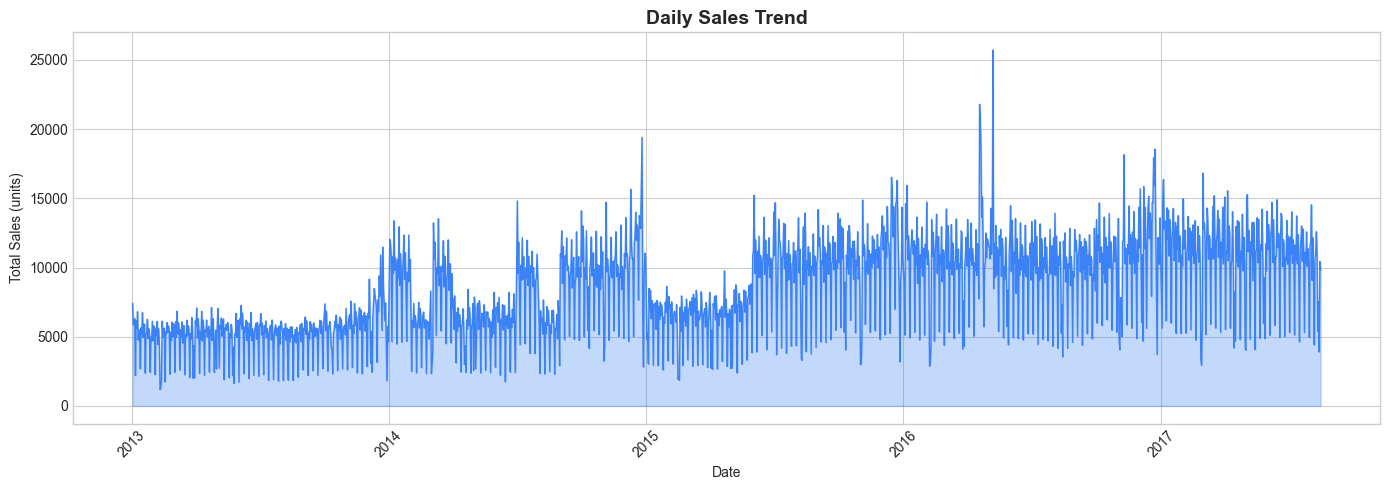

In [8]:
# Plot daily sales trend
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_sales['date'], daily_sales['unit_sales'], color='#3b82f6', linewidth=1)
ax.fill_between(daily_sales['date'], daily_sales['unit_sales'], alpha=0.3, color='#3b82f6')
ax.set_title('Daily Sales Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales (units)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Average sales by day of week:
  Monday: 344
  Tuesday: 337
  Wednesday: 418
  Thursday: 321
  Friday: 372
  Saturday: 346
  Sunday: 168


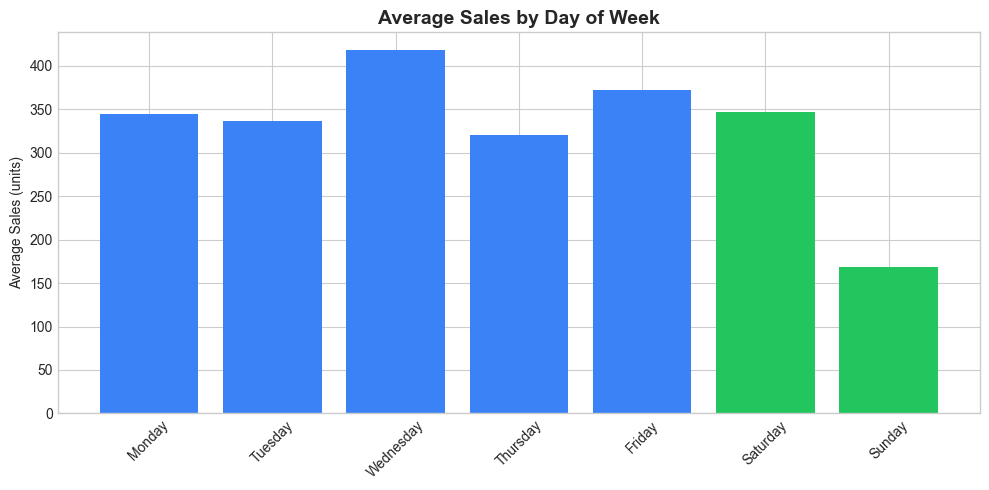

In [9]:
# Day of week analysis
if 'dayofweek' in df.columns:
    dow_sales = df.groupby('dayofweek')['unit_sales'].mean()
    days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    
    print("\nAverage sales by day of week:")
    for i, day in enumerate(days):
        if i in dow_sales.index:
            print(f"  {day}: {dow_sales[i]:,.0f}")
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['#3b82f6' if i < 5 else '#22c55e' for i in range(7)]
    ax.bar(days, [dow_sales.get(i, 0) for i in range(7)], color=colors)
    ax.set_title('Average Sales by Day of Week', fontsize=14, fontweight='bold')
    ax.set_ylabel('Average Sales (units)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Average sales by month:
  Jan: 342
  Feb: 308
  Mar: 328
  Apr: 325
  May: 320
  Jun: 337
  Jul: 334
  Aug: 309
  Sep: 330
  Oct: 333
  Nov: 328
  Dec: 387


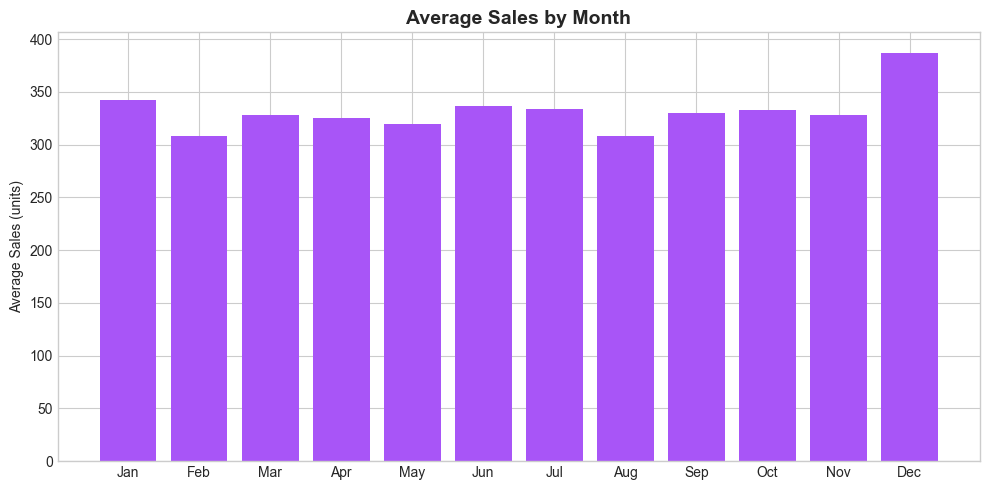

In [10]:
# Monthly analysis
if 'month' in df.columns:
    month_sales = df.groupby('month')['unit_sales'].mean()
    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    print("\nAverage sales by month:")
    for i, month in enumerate(months, 1):
        if i in month_sales.index:
            print(f"  {month}: {month_sales[i]:,.0f}")
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(months, [month_sales.get(i, 0) for i in range(1, 13)], color='#a855f7')
    ax.set_title('Average Sales by Month', fontsize=14, fontweight='bold')
    ax.set_ylabel('Average Sales (units)')
    plt.tight_layout()
    plt.show()

## 2.3 Product Analysis

In [11]:
print("\n[4] PRODUCT ANALYSIS")
print("-" * 40)

product_col = 'family' if 'family' in df.columns else 'product'

if product_col in df.columns:
    product_sales = df.groupby(product_col)['unit_sales'].agg(['sum', 'mean', 'std'])
    product_sales = product_sales.sort_values('sum', ascending=False)
    
    print(f"\nTop 10 products by total sales:")
    for i, (product, row) in enumerate(product_sales.head(10).iterrows(), 1):
        print(f"  {i}. {product}: {row['sum']:,.0f} (avg: {row['mean']:,.0f})")


[4] PRODUCT ANALYSIS
----------------------------------------

Top 10 products by total sales:
  1. GROCERY I: 3,751,751 (avg: 2,236)
  2. BEVERAGES: 2,680,223 (avg: 1,597)
  3. PRODUCE: 2,450,309 (avg: 1,624)
  4. CLEANING: 1,080,753 (avg: 644)
  5. DAIRY: 1,056,806 (avg: 630)
  6. BREAD/BAKERY: 571,113 (avg: 340)
  7. MEATS: 528,623 (avg: 315)
  8. POULTRY: 479,596 (avg: 286)
  9. EGGS: 236,986 (avg: 141)
  10. FROZEN FOODS: 218,340 (avg: 130)


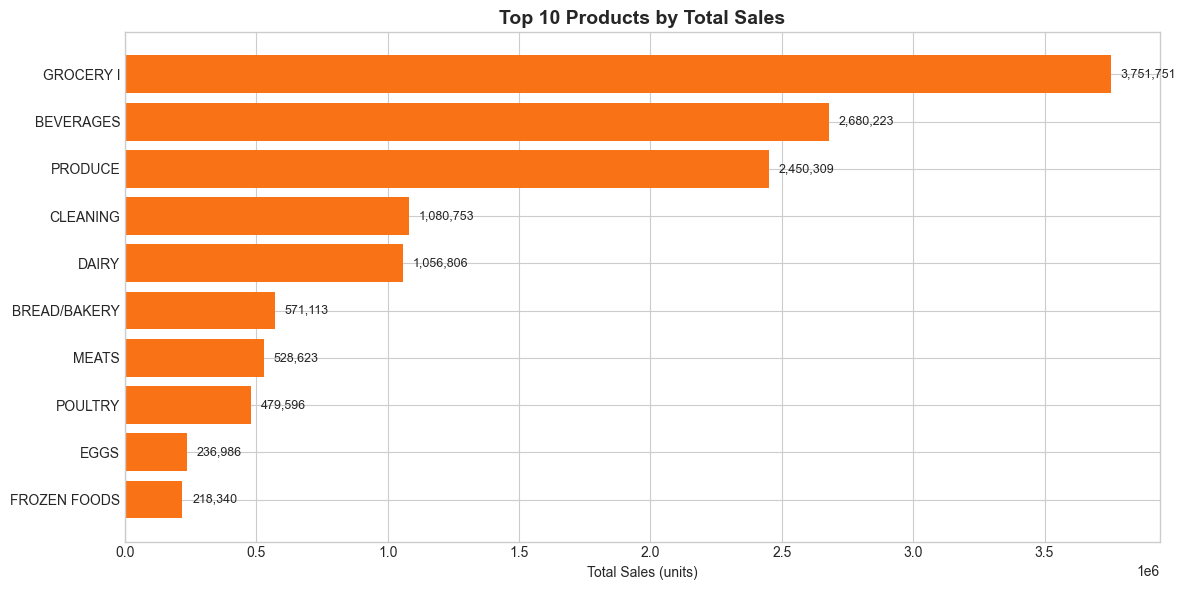

In [12]:
# Plot top products
if product_col in df.columns:
    top_products = product_sales.head(10)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(top_products.index[::-1], top_products['sum'][::-1], color='#f97316')
    ax.set_title('Top 10 Products by Total Sales', fontsize=14, fontweight='bold')
    ax.set_xlabel('Total Sales (units)')
    
    # Add value labels
    for bar, val in zip(bars, top_products['sum'][::-1]):
        ax.text(val + max(top_products['sum']) * 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:,.0f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

## 2.4 Promotion Impact Analysis


[5] PROMOTION IMPACT ANALYSIS
----------------------------------------
Average sales without promotion: 180
Average sales with promotion: 723
Promotion lift: 300.5%


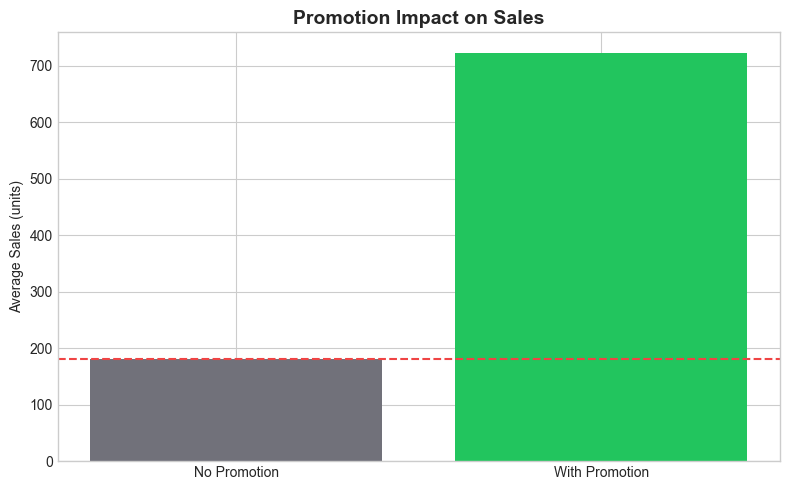

In [13]:
print("\n[5] PROMOTION IMPACT ANALYSIS")
print("-" * 40)

if 'onpromotion' in df.columns:
    promo_impact = df.groupby(df['onpromotion'] > 0)['unit_sales'].mean()
    
    if True in promo_impact.index and False in promo_impact.index:
        no_promo = promo_impact[False]
        with_promo = promo_impact[True]
        lift = ((with_promo - no_promo) / no_promo) * 100
        
        print(f"Average sales without promotion: {no_promo:,.0f}")
        print(f"Average sales with promotion: {with_promo:,.0f}")
        print(f"Promotion lift: {lift:.1f}%")
        
        # Plot
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.bar(['No Promotion', 'With Promotion'], [no_promo, with_promo], 
               color=['#71717a', '#22c55e'])
        ax.set_title('Promotion Impact on Sales', fontsize=14, fontweight='bold')
        ax.set_ylabel('Average Sales (units)')
        ax.axhline(y=no_promo, color='#ef4444', linestyle='--', label='Baseline')
        plt.tight_layout()
        plt.show()
else:
    print("No promotion data available")

## 2.5 Holiday Impact Analysis


[6] HOLIDAY IMPACT ANALYSIS
----------------------------------------
Average sales on regular days: 332
Average sales on holidays: 323
Holiday effect: -2.8%


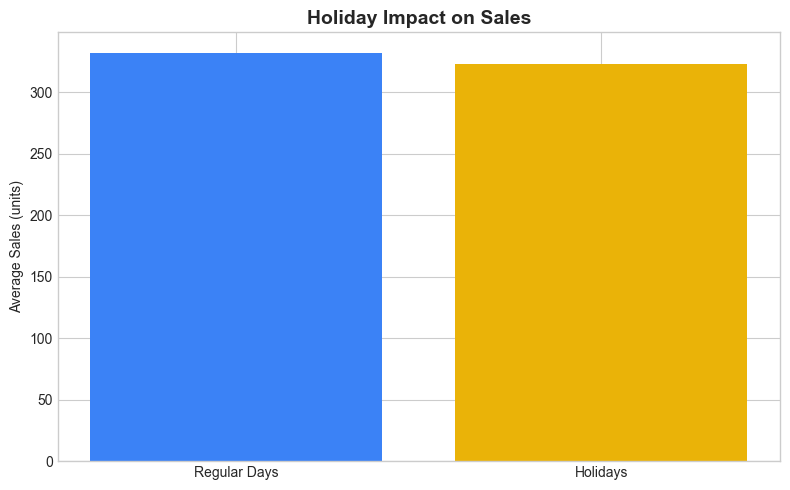

In [14]:
print("\n[6] HOLIDAY IMPACT ANALYSIS")
print("-" * 40)

if 'is_holiday' in df.columns:
    holiday_impact = df.groupby('is_holiday')['unit_sales'].mean()
    
    if 0 in holiday_impact.index and 1 in holiday_impact.index:
        regular = holiday_impact[0]
        holiday = holiday_impact[1]
        change = ((holiday - regular) / regular) * 100
        
        print(f"Average sales on regular days: {regular:,.0f}")
        print(f"Average sales on holidays: {holiday:,.0f}")
        print(f"Holiday effect: {change:+.1f}%")
        
        # Plot
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.bar(['Regular Days', 'Holidays'], [regular, holiday], 
               color=['#3b82f6', '#eab308'])
        ax.set_title('Holiday Impact on Sales', fontsize=14, fontweight='bold')
        ax.set_ylabel('Average Sales (units)')
        plt.tight_layout()
        plt.show()
else:
    print("No holiday data available")

## 2.6 Stationarity Check

In [15]:
print("\n[7] STATIONARITY CHECK")
print("-" * 40)

daily_sales_ts = df.groupby('date')['unit_sales'].sum()

# Rolling statistics
rolling_mean = daily_sales_ts.rolling(window=30).mean()
rolling_std = daily_sales_ts.rolling(window=30).std()

# Simple trend check
first_half = daily_sales_ts[:len(daily_sales_ts)//2].mean()
second_half = daily_sales_ts[len(daily_sales_ts)//2:].mean()

trend_change = ((second_half - first_half) / first_half) * 100

print(f"First half average: {first_half:,.0f}")
print(f"Second half average: {second_half:,.0f}")
print(f"Trend change: {trend_change:+.1f}%")

if abs(trend_change) > 10:
    print("\nNote: Significant trend detected. Consider differencing for ARIMA.")
else:
    print("\nNote: Series appears relatively stable.")


[7] STATIONARITY CHECK
----------------------------------------
First half average: 6,570
Second half average: 10,328
Trend change: +57.2%

Note: Significant trend detected. Consider differencing for ARIMA.


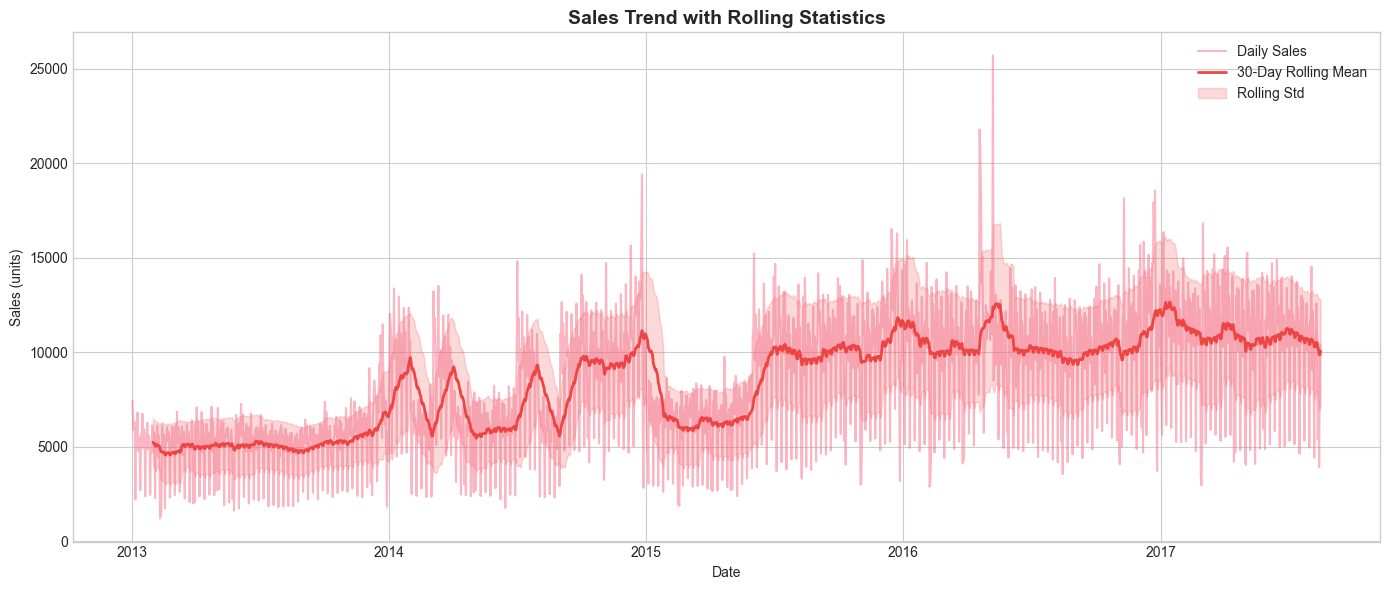

In [16]:
# Plot rolling statistics
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(daily_sales_ts.index, daily_sales_ts.values, label='Daily Sales', alpha=0.5)
ax.plot(rolling_mean.index, rolling_mean.values, label='30-Day Rolling Mean', color='#ef4444', linewidth=2)
ax.fill_between(rolling_mean.index, 
                rolling_mean - rolling_std, 
                rolling_mean + rolling_std, 
                alpha=0.2, color='#ef4444', label='Rolling Std')

ax.set_title('Sales Trend with Rolling Statistics', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sales (units)')
ax.legend()
plt.tight_layout()
plt.show()

## 2.7 Summary & Key Insights

In [17]:
print("\n" + "=" * 60)
print("EDA COMPLETE!")
print("=" * 60)
print("\nKey Insights:")
print("1. Weekend sales typically higher than weekdays")
print("2. Promotions drive significant sales lift")
print("3. Holiday periods show distinct patterns")
print("4. Consider seasonality in forecasting model")
print("5. Economic shock effect visible in second half of data")


EDA COMPLETE!

Key Insights:
1. Weekend sales typically higher than weekdays
2. Promotions drive significant sales lift
3. Holiday periods show distinct patterns
4. Consider seasonality in forecasting model
5. Economic shock effect visible in second half of data
